# Tensegrity Manipulator — Kinematic Schematic

Klein-style side-view schematic of the 5-DoF tensegrity manipulator. The drawing emphasises the joint *types* (prismatic, revolute, universal/Hooke) and the three functional subsystems; quantitative segment lengths are deliberately omitted because they appear in the link/joint tables further down the chapter.

Output: SVG written to `doc/Theses/project_thesis/assets/figures/robot/tensegrity_kinematic_schematic.svg` for inclusion in §4.2 of the project thesis.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch
import numpy as np

# ── Project palette (mirrors thesis-style.typ) ──────────────────────────
C_STROKE = "#2C2C2C"
C_LINK   = "#1F4E79"   # FAPS blue, darkened
C_REV    = "#3F7F3F"   # FAPS green, darkened
C_PRIS   = "#CC6600"
C_LO     = "#B22222"   # link-origin highlight
C_ROD    = "#3A6FA8"
C_GRIP   = "#BFBFBF"
C_INSET_BG  = "#F8F8F8"
C_GROUP_BASE = "#7A4F00"
C_GROUP_ARM  = "#1B4F72"
C_GROUP_EE   = "#1E5631"

## Drawing helpers

In [7]:
def ceiling(ax, x0, x1, y, n=18, hatch_len=0.18):
    ax.plot([x0, x1], [y, y], color=C_STROKE, lw=1.2)
    for x in np.linspace(x0, x1, n):
        ax.plot([x, x - hatch_len], [y, y + hatch_len * 1.4],
                color=C_STROKE, lw=0.6)

def lo_marker(ax, p, label, side="left", size=0.12):
    """Prominent link-origin marker: red square outline + crosshair + bold label."""
    x, y = p
    ax.add_patch(Rectangle((x - size, y - size), 2*size, 2*size,
                           facecolor="white", edgecolor=C_LO,
                           lw=1.2, zorder=8))
    ax.plot([x - size*0.7, x + size*0.7], [y, y],
            color=C_LO, lw=0.8, zorder=9)
    ax.plot([x, x], [y - size*0.7, y + size*0.7],
            color=C_LO, lw=0.8, zorder=9)
    if side == "left":
        ax.text(x - size - 0.18, y, label, ha="right", va="center",
                fontsize=7.8, color=C_LO, fontweight="bold")
    else:
        ax.text(x + size + 0.18, y, label, ha="left", va="center",
                fontsize=7.8, color=C_LO, fontweight="bold")

def rev_joint(ax, p, label=None, radius=0.20, side="right"):
    """Revolute joint: open circle (axis perpendicular to drawing plane)."""
    x, y = p
    ax.add_patch(Circle((x, y), radius, facecolor="white",
                        edgecolor=C_REV, lw=1.2, zorder=4))
    ax.add_patch(Circle((x, y), 0.05, color=C_REV, zorder=5))
    if label is not None:
        if side == "right":
            ax.text(x + radius + 0.14, y, label, ha="left", va="center",
                    fontsize=7.5, color=C_STROKE)
        else:
            ax.text(x - radius - 0.14, y, label, ha="right", va="center",
                    fontsize=7.5, color=C_STROKE)

def universal_joint(ax, p, label=None, radius=0.30, side="right"):
    """Klein-style 2-DoF wrist depicted as a cardan/Hooke joint:
    two outer yokes plus a central cross indicating the two perpendicular
    rotation axes (wrist_x and wrist_y)."""
    x, y = p
    # Outer yoke arms (vertical) — proximal yoke (above) and distal yoke (below)
    yoke = 0.18
    ax.plot([x - radius, x - radius], [y + yoke, y + radius],
            color=C_REV, lw=1.3)
    ax.plot([x + radius, x + radius], [y + yoke, y + radius],
            color=C_REV, lw=1.3)
    ax.plot([x - radius, x + radius], [y + radius, y + radius],
            color=C_REV, lw=1.3)
    ax.plot([x - radius, x - radius], [y - yoke, y - radius],
            color=C_REV, lw=1.3)
    ax.plot([x + radius, x + radius], [y - yoke, y - radius],
            color=C_REV, lw=1.3)
    ax.plot([x - radius, x + radius], [y - radius, y - radius],
            color=C_REV, lw=1.3)
    # Central cross (the spider): two perpendicular pivot axes
    ax.plot([x - yoke, x + yoke], [y, y], color=C_REV, lw=1.5, zorder=5)
    ax.plot([x, x], [y - yoke, y + yoke], color=C_REV, lw=1.5, zorder=5)
    # Pivot caps at the four cross ends
    for dx, dy in [(yoke, 0), (-yoke, 0), (0, yoke), (0, -yoke)]:
        ax.add_patch(Circle((x + dx, y + dy), 0.05,
                            facecolor=C_REV, edgecolor="none", zorder=6))
    # Hub
    ax.add_patch(Circle((x, y), 0.06, facecolor="white",
                        edgecolor=C_REV, lw=0.9, zorder=7))
    if label is not None:
        if side == "right":
            ax.text(x + radius + 0.20, y, label, ha="left", va="center",
                    fontsize=7.5, color=C_STROKE)
        else:
            ax.text(x - radius - 0.20, y, label, ha="right", va="center",
                    fontsize=7.5, color=C_STROKE)

def prism_h(ax, p, label, w=1.2, h=0.40):
    x, y = p
    ax.add_patch(Rectangle((x - w/2, y - h/2), w, h,
                           facecolor="white", edgecolor=C_PRIS, lw=1.0))
    ax.annotate("", xy=(x + w/2 - 0.12, y), xytext=(x - w/2 + 0.12, y),
                arrowprops=dict(arrowstyle="<->", color=C_PRIS, lw=0.9))
    ax.text(x + w/2 + 0.20, y, label, ha="left", va="center",
            fontsize=7.5, color=C_STROKE)

def prism_v(ax, p, label, w=0.40, h=1.0):
    x, y = p
    ax.add_patch(Rectangle((x - w/2, y - h/2), w, h,
                           facecolor="white", edgecolor=C_PRIS, lw=1.0))
    ax.annotate("", xy=(x, y + h/2 - 0.12), xytext=(x, y - h/2 + 0.12),
                arrowprops=dict(arrowstyle="<->", color=C_PRIS, lw=0.9))
    ax.text(x + w/2 + 0.20, y, label, ha="left", va="center",
            fontsize=7.5, color=C_STROKE)

def link(ax, p1, p2, lw=2.6):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=C_LINK, lw=lw,
            solid_capstyle="round", zorder=2)

def subsystem_bracket(ax, x, y_top, y_bot, label, color):
    """Vertical curly bracket grouping a subsystem region (drawn on the LEFT)."""
    tip = 0.14
    ymid = (y_top + y_bot) / 2
    # Outer vertical line + tip caps
    ax.plot([x, x], [y_bot + 0.05, ymid - 0.10],
            color=color, lw=1.2)
    ax.plot([x, x], [ymid + 0.10, y_top - 0.05],
            color=color, lw=1.2)
    # End hooks
    ax.plot([x, x + tip], [y_top - 0.05, y_top - 0.05],
            color=color, lw=1.2)
    ax.plot([x, x + tip], [y_bot + 0.05, y_bot + 0.05],
            color=color, lw=1.2)
    # Middle pointer
    ax.plot([x, x - tip], [ymid + 0.10, ymid],
            color=color, lw=1.2)
    ax.plot([x, x - tip], [ymid - 0.10, ymid],
            color=color, lw=1.2)
    ax.text(x - tip - 0.18, ymid, label, ha="right", va="center",
            fontsize=9.5, color=color, fontweight="bold", rotation=90)

## Build the schematic

Saved → /Users/georg/Projects/studentische-arbeiten/doc/Theses/project_thesis/assets/figures/robot/tensegrity_kinematic_schematic.svg


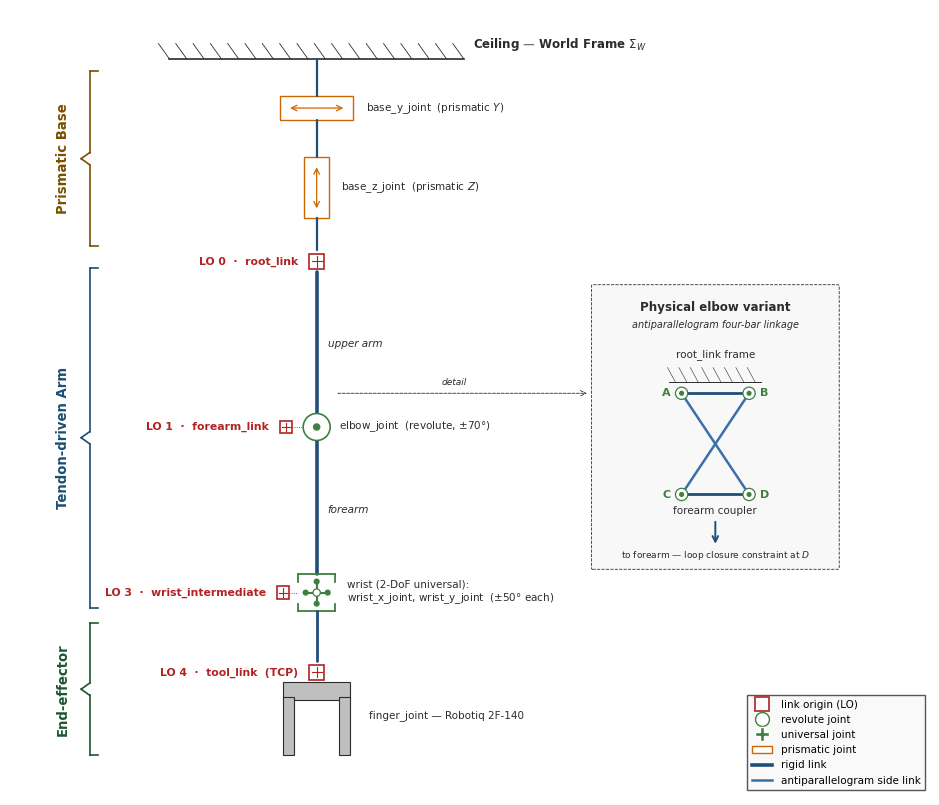

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 8.5))

# ── Layout coordinates (axis units = arbitrary cm) ───────────────────────
xc = 4.5           # main column x
y_ceil    = 12.5
y_base_y  = 11.7
y_base_z  = 10.4
y_lo0     = 9.20
y_elbow   = 6.50
y_lo1     = 6.50   # elbow joint == LO 1 of forearm
y_wrist   = 3.80   # universal joint center
y_lo3     = y_wrist  # wrist intermediate frame coincides at the cross
y_lo4     = 2.50   # tool_link

# ── Ceiling ──────────────────────────────────────────────────────────────
ceiling(ax, xc - 2.4, xc + 2.4, y_ceil)
ax.text(xc + 2.55, y_ceil + 0.10,
        r"Ceiling — World Frame $\Sigma_W$",
        ha="left", va="bottom", fontsize=8.5, color=C_STROKE,
        fontweight="bold")

# ── Base prismatic joints (subsystem 1) ──────────────────────────────────
link(ax, (xc, y_ceil), (xc, y_base_y + 0.20), lw=1.6)
prism_h(ax, (xc, y_base_y), r"base_y_joint  (prismatic $Y$)")
link(ax, (xc, y_base_y - 0.20), (xc, y_base_z + 0.50), lw=1.6)
prism_v(ax, (xc, y_base_z), r"base_z_joint  (prismatic $Z$)")
link(ax, (xc, y_base_z - 0.50), (xc, y_lo0 + 0.18), lw=1.6)

# ── LO 0 root_link ───────────────────────────────────────────────────────
lo_marker(ax, (xc, y_lo0), "LO 0  ·  root_link", side="left")

# ── Upper arm (root → elbow) ─────────────────────────────────────────────
link(ax, (xc, y_lo0 - 0.18), (xc, y_elbow + 0.20))
ax.text(xc + 0.18, (y_lo0 + y_elbow)/2, "upper arm",
        ha="left", va="center", fontsize=7.5, color=C_STROKE,
        style="italic")

# ── Elbow joint ──────────────────────────────────────────────────────────
rev_joint(ax, (xc, y_elbow), radius=0.22,
          label=r"elbow_joint  (revolute, $\pm 70°$)")
lo_marker(ax, (xc - 0.50, y_elbow), "LO 1  ·  forearm_link",
          side="left", size=0.10)
ax.plot([xc - 0.50 + 0.10, xc - 0.22],
        [y_elbow, y_elbow],
        color=C_LO, lw=0.6, linestyle=":")

# ── Forearm (elbow → wrist) ──────────────────────────────────────────────
link(ax, (xc, y_elbow - 0.20), (xc, y_wrist + 0.30))
ax.text(xc + 0.18, (y_elbow + y_wrist)/2, "forearm",
        ha="left", va="center", fontsize=7.5, color=C_STROKE,
        style="italic")

# ── Wrist as 2-DoF universal/Hooke joint ─────────────────────────────────
universal_joint(ax, (xc, y_wrist), radius=0.30,
                label=r"wrist (2-DoF universal):" + "\n" +
                      r"wrist_x_joint, wrist_y_joint  ($\pm 50°$ each)")
lo_marker(ax, (xc - 0.55, y_wrist), "LO 3  ·  wrist_intermediate",
          side="left", size=0.10)
ax.plot([xc - 0.55 + 0.10, xc - 0.30],
        [y_wrist, y_wrist], color=C_LO, lw=0.6, linestyle=":")

# ── End-effector flange + Robotiq gripper ────────────────────────────────
link(ax, (xc, y_wrist - 0.30), (xc, y_lo4 + 0.18), lw=2.0)
lo_marker(ax, (xc, y_lo4), "LO 4  ·  tool_link  (TCP)", side="left")
gx, gy = xc, y_lo4 - 0.15 #- 0.45
ax.add_patch(Rectangle((gx - 0.55, gy - 0.30), 1.10, 0.30,
                       facecolor=C_GRIP, edgecolor=C_STROKE, lw=0.8))
ax.add_patch(Rectangle((gx - 0.55, gy - 1.20), 0.18, 0.95,
                       facecolor=C_GRIP, edgecolor=C_STROKE, lw=0.8))
ax.add_patch(Rectangle((gx + 0.37, gy - 1.20), 0.18, 0.95,
                       facecolor=C_GRIP, edgecolor=C_STROKE, lw=0.8))
ax.text(gx + 0.85, gy - 0.55,
        r"finger_joint — Robotiq 2F-140",
        ha="left", va="center", fontsize=7.5, color=C_STROKE)

# ── Subsystem brackets on the LEFT ───────────────────────────────────────
x_brk = 0.8
subsystem_bracket(ax, x_brk, y_ceil - 0.15, y_lo0 + 0.20,
                  "Prismatic Base", C_GROUP_BASE)
subsystem_bracket(ax, x_brk, y_lo0 - 0.05, y_wrist - 0.30,
                  "Tendon-driven Arm", C_GROUP_ARM)
subsystem_bracket(ax, x_brk, y_wrist - 0.45, gy - 1.25,
                  "End-effector", C_GROUP_EE)

# ── INSET: physical antiparallelogram elbow variant ──────────────────────
ix, iy = 11.0, 6.50
iw, ih = 4.0, 4.6
ax.add_patch(FancyBboxPatch((ix - iw/2, iy - ih/2), iw, ih,
                            boxstyle="round,pad=0.02",
                            facecolor=C_INSET_BG,
                            edgecolor=C_STROKE, lw=0.6,
                            linestyle="--"))
ax.text(ix, iy + ih/2 - 0.25, "Physical elbow variant",
        ha="center", va="top", fontsize=8.5, color=C_STROKE,
        fontweight="bold")
ax.text(ix, iy + ih/2 - 0.55, "antiparallelogram four-bar linkage",
        ha="center", va="top", fontsize=7, color=C_STROKE,
        style="italic")

# Linkage geometry
A = (ix - 0.55, iy + 0.55)
B = (ix + 0.55, iy + 0.55)
C = (ix - 0.55, iy - 1.10)
D = (ix + 0.55, iy - 1.10)

# Mini-ceiling for the root_link frame
ax.plot([A[0] - 0.20, B[0] + 0.20], [A[1] + 0.18, A[1] + 0.18],
        color=C_STROKE, lw=0.7)
for x in np.linspace(A[0] - 0.10, B[0] + 0.10, 8):
    ax.plot([x, x - 0.13], [A[1] + 0.18, A[1] + 0.42],
            color=C_STROKE, lw=0.4)
ax.text(ix, A[1] + 0.55, "root_link frame",
        ha="center", va="bottom", fontsize=7.5, color=C_STROKE)

# Frame bar A–B and coupler bar C–D
link(ax, A, B, lw=2.0)
link(ax, C, D, lw=2.0)
ax.text(ix, D[1] - 0.18, "forearm coupler",
        ha="center", va="top", fontsize=7.5, color=C_STROKE)

# Crossed side links
ax.plot([A[0], D[0]], [A[1], D[1]], color=C_ROD, lw=1.8)
ax.plot([B[0], C[0]], [B[1], C[1]], color=C_ROD, lw=1.8)

# Joint markers A,B,C,D
for p, lbl, ha in [(A, "A", "right"), (B, "B", "left"),
                   (C, "C", "right"), (D, "D", "left")]:
    ax.add_patch(Circle(p, 0.10, facecolor="white",
                        edgecolor=C_REV, lw=0.9, zorder=5))
    ax.add_patch(Circle(p, 0.03, color=C_REV, zorder=6))
    off = -0.18 if ha == "right" else 0.18
    ax.text(p[0] + off, p[1], lbl, ha=ha, va="center",
            fontsize=8, color=C_REV, fontweight="bold")

# Loop-closure arrow downward from coupler
ax.annotate("", xy=(ix, D[1] - 0.85), xytext=(ix, D[1] - 0.40),
            arrowprops=dict(arrowstyle="->", color=C_LINK, lw=1.4))
ax.text(ix, D[1] - 0.88,
        "to forearm — loop closure constraint at $D$",
        ha="center", va="top", fontsize=6.5, color=C_STROKE)

# Connector main → inset (above the elbow joint label)
ax.annotate("", xy=(ix - iw/2 - 0.05, y_elbow + 0.55),
            xytext=(xc + 0.30, y_elbow + 0.55),
            arrowprops=dict(arrowstyle="->", color=C_STROKE,
                            lw=0.6, linestyle="--"))
ax.text((xc + ix - iw/2) / 2, y_elbow + 0.65, "detail",
        ha="center", va="bottom", fontsize=6.5, color=C_STROKE,
        style="italic")

# ── Legend ───────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor="white", markeredgecolor=C_LO,
           markeredgewidth=1.2, markersize=10,
           label="link origin (LO)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor=C_REV, markeredgewidth=1.0, markersize=10,
           label="revolute joint"),
    Line2D([0], [0], marker="P", color="w", markerfacecolor=C_REV,
           markersize=10, label="universal joint"),
    mpatches.Patch(facecolor="white", edgecolor=C_PRIS,
                   label="prismatic joint"),
    Line2D([0], [0], color=C_LINK, lw=2.6, label="rigid link"),
    Line2D([0], [0], color=C_ROD, lw=1.8,
           label="antiparallelogram side link"),
]
ax.legend(handles=legend_handles, loc="lower right",
          fontsize=7.5, frameon=True, fancybox=False,
          edgecolor=C_STROKE, facecolor=C_INSET_BG,
          bbox_to_anchor=(1.0, 0.0))

# ── Axes cosmetics ───────────────────────────────────────────────────────
ax.set_xlim(-0.5, 14.5)
ax.set_ylim(0.5, 13.3)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

# Export SVG
out_path = Path("../Theses/project_thesis/assets/figures/robot/tensegrity_kinematic_schematic.svg")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="svg", bbox_inches="tight")
print(f"Saved → {out_path.resolve()}")
plt.show()

## Link parameters (per-link masses and segment lengths)

Values mirror `tab:link_params` in §4.2 of the thesis. Segment lengths are taken from the CAD assembly; masses are the values configured on the simulation rigid bodies (Klein 2023).

In [9]:
import pandas as pd

link_params = pd.DataFrame([
    {"link": "root_link",                "segment_to_next": "upper arm (root → elbow)",  "length_mm": 430, "mass_kg": 2.000, "notes": "aluminium bracket assembly"},
    {"link": "forearm_link (disc)",      "segment_to_next": "forearm (elbow → wrist)",   "length_mm": 406, "mass_kg": 2.092, "notes": "single rigid body, disc-approx variant"},
    {"link": "forearm_link (physical)",  "segment_to_next": "forearm tube only",         "length_mm": 406, "mass_kg": 1.900, "notes": "physical antiparallelogram variant"},
    {"link": "rod_left / rod_right",     "segment_to_next": "crossed side link",         "length_mm": 150, "mass_kg": 0.096, "notes": "two rods, physical variant only"},
    {"link": "wrist_intermediate_link",  "segment_to_next": "wrist (intermediate → tool)", "length_mm": 136, "mass_kg": 0.400, "notes": "two-axis wrist housing"},
    {"link": "tool_link",                "segment_to_next": "—",                          "length_mm": None, "mass_kg": 0.001, "notes": "massless TCP frame"},
])
link_params

,link,segment_to_next,length_mm,mass_kg,notes
0,root_link,upper arm (root → elbow),430.0,2.000,aluminium bracket assembly
1,forearm_link (disc),forearm (elbow → wrist),406.0,2.092,"single rigid body, disc-approx variant"
2,forearm_link (physical),forearm tube only,406.0,1.900,physical antiparallelogram variant
3,rod_left / rod_right,crossed side link,150.0,0.096,"two rods, physical variant only"
4,wrist_intermediate_link,wrist (intermediate → tool),136.0,0.400,two-axis wrist housing
5,tool_link,—,NaN,0.001,massless TCP frame


## Joint parameters (kinematic ranges and effort limits)

Mirrors `tab:joint_ranges` in §4.2. Effort limits are derived from the motor and tendon specifications described in §4.2.3.

In [10]:
joint_params = pd.DataFrame([
    {"joint": "base_y_joint",  "type": "prismatic Y",      "range": "±0.5 m",          "effort_Nm": 200.0},
    {"joint": "base_z_joint",  "type": "prismatic Z",      "range": "−0.5 … 0.0 m",    "effort_Nm": 200.0},
    {"joint": "elbow_joint",   "type": "revolute (pitch)", "range": "±70°",            "effort_Nm": 35.0},
    {"joint": "wrist_y_joint", "type": "revolute (pitch)", "range": "±50°",            "effort_Nm": 3.0},
    {"joint": "wrist_x_joint", "type": "revolute (roll)",  "range": "±50°",            "effort_Nm": 3.0},
    {"joint": "finger_joint",  "type": "revolute (gripper)", "range": "0 … 0.7854 rad", "effort_Nm": 200.0},
])
joint_params

,joint,type,range,effort_Nm
0,base_y_joint,prismatic Y,±0.5 m,200.0
1,base_z_joint,prismatic Z,−0.5 … 0.0 m,200.0
2,elbow_joint,revolute (pitch),±70°,35.0
3,wrist_y_joint,revolute (pitch),±50°,3.0
4,wrist_x_joint,revolute (roll),±50°,3.0
5,finger_joint,revolute (gripper),0 … 0.7854 rad,200.0


The physical antiparallelogram variant additionally exposes the four passive linkage joints `rod_left_joint`, `rod_right_joint`, `coupler_left_joint`, `coupler_right_joint`. The last of these acts as the PhysX loop-closure constraint and is excluded from the articulation tree.